In [1]:
# ============================================================
# Cell 1: Environment Setup
# ============================================================
import os

# Clone the iTransformer repository
if not os.path.exists('iTransformer'):
    !git clone https://github.com/thuml/iTransformer.git

# Install core dependencies
!pip install -q torch numpy pandas scikit-learn matplotlib reformer_pytorch

print("Environment setup complete.")

Environment setup complete.


In [2]:
# ============================================================
# Cell 3: Imports & Global Configuration
# ============================================================
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from math import sqrt

sys.path.insert(0, './iTransformer')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ---- Hyperparameters ----
SEQUENCE_LENGTH = 30
MAX_RUL = 125
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 15  # Early stopping patience

# iTransformer architecture
D_MODEL = 128
N_HEADS = 4
E_LAYERS = 3
D_FF = 256
DROPOUT = 0.15
ACTIVATION = 'gelu'

DATA_ROOT = '/content/dataset'
subsets = ['FD001', 'FD002', 'FD003', 'FD004']

COLUMN_NAMES = (
    ['unit_id', 'cycle'] +
    [f'op{i}' for i in range(1, 4)] +
    [f's{i}' for i in range(1, 22)]
)
OP_COLS = ['op1', 'op2', 'op3']
SENSOR_COLS = [f's{i}' for i in range(1, 22)]

print(f"Sequence length: {SEQUENCE_LENGTH}, Max RUL cap: {MAX_RUL}")
print(f"Epochs: {EPOCHS}, Early stopping patience: {PATIENCE}")


Using device: cuda
Sequence length: 30, Max RUL cap: 125
Epochs: 100, Early stopping patience: 15


In [3]:
# ============================================================
# Cell 4: Data Loading & Preprocessing (with regime normalization)
# ============================================================

def load_cmapss_data(data_root, subset_name):
    train_path = os.path.join(data_root, f'train_{subset_name}.txt')
    test_path  = os.path.join(data_root, f'test_{subset_name}.txt')
    rul_path   = os.path.join(data_root, f'RUL_{subset_name}.txt')
    train_df = pd.read_csv(train_path, sep=r'\s+', header=None, names=COLUMN_NAMES)
    test_df  = pd.read_csv(test_path,  sep=r'\s+', header=None, names=COLUMN_NAMES)
    rul_df   = pd.read_csv(rul_path,   sep=r'\s+', header=None, names=['rul'])
    return train_df, test_df, rul_df


def add_rul_to_train(train_df, max_rul=MAX_RUL):
    max_cycles = train_df.groupby('unit_id')['cycle'].max().reset_index()
    max_cycles.columns = ['unit_id', 'max_cycle']
    train_df = train_df.merge(max_cycles, on='unit_id', how='left')
    train_df['rul'] = train_df['max_cycle'] - train_df['cycle']
    train_df['rul'] = train_df['rul'].clip(upper=max_rul)
    train_df.drop('max_cycle', axis=1, inplace=True)
    return train_df


def detect_n_regimes(train_df):
    """Auto-detect the number of operating regimes from the op settings."""
    op_data = train_df[OP_COLS].values
    op_rounded = np.round(op_data, decimals=4)
    unique_conditions = np.unique(op_rounded, axis=0)
    n = len(unique_conditions)
    return max(1, min(n, 6))


def regime_normalize(train_df, test_df, sensor_cols, op_cols):
    """
    Cluster operating conditions with KMeans, then normalize sensors
    within EACH cluster separately. This removes operating-condition
    effects and exposes the pure degradation signal.
    """
    n_regimes = detect_n_regimes(train_df)

    if n_regimes <= 1:
        # Single regime: just do global StandardScaler normalization
        scaler = StandardScaler()
        train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
        test_df[sensor_cols]  = scaler.transform(test_df[sensor_cols])
        return train_df, test_df

    # Cluster operating conditions
    kmeans = KMeans(n_clusters=n_regimes, n_init=10, random_state=42)
    train_df['regime'] = kmeans.fit_predict(train_df[op_cols].values)
    test_df['regime'] = kmeans.predict(test_df[op_cols].values)

    # Normalize sensors WITHIN each regime
    scalers = {}
    for r in range(n_regimes):
        mask_train = train_df['regime'] == r
        scaler = StandardScaler()
        if mask_train.sum() > 0:
            train_df.loc[mask_train, sensor_cols] = scaler.fit_transform(
                train_df.loc[mask_train, sensor_cols]
            )
        scalers[r] = scaler

        mask_test = test_df['regime'] == r
        if mask_test.sum() > 0:
            test_df.loc[mask_test, sensor_cols] = scaler.transform(
                test_df.loc[mask_test, sensor_cols]
            )

    train_df.drop('regime', axis=1, inplace=True)
    test_df.drop('regime', axis=1, inplace=True)
    return train_df, test_df


def drop_constant_features(train_df, test_df, sensor_cols, threshold=0.01):
    """Automatically detect and drop sensors with near-zero variance."""
    variances = train_df[sensor_cols].var()
    cols_to_keep = variances[variances > threshold].index.tolist()
    cols_to_drop = [c for c in sensor_cols if c not in cols_to_keep]
    if cols_to_drop:
        print(f"    Dropping constant sensors: {cols_to_drop}")
    return cols_to_keep


def apply_ema_smoothing(df, cols, alpha=0.3):
    """Apply exponential moving average smoothing per engine unit."""
    smoothed = df.copy()
    for uid in df['unit_id'].unique():
        mask = df['unit_id'] == uid
        smoothed.loc[mask, cols] = df.loc[mask, cols].ewm(alpha=alpha, adjust=False).mean()
    return smoothed


def preprocess_subset(data_root, subset_name):
    """Complete preprocessing pipeline for one subset."""
    print(f"[{subset_name}] Loading data...")
    train_df, test_df, rul_df = load_cmapss_data(data_root, subset_name)
    print(f"  Train: {len(train_df)} rows, {train_df['unit_id'].nunique()} engines")
    print(f"  Test:  {len(test_df)} rows, {test_df['unit_id'].nunique()} engines")

    # Add RUL labels
    train_df = add_rul_to_train(train_df, max_rul=MAX_RUL)

    # Regime-aware normalization
    n_regimes = detect_n_regimes(train_df)
    print(f"  Detected {n_regimes} operating regime(s)")
    train_df, test_df = regime_normalize(train_df, test_df, SENSOR_COLS, OP_COLS)

    # Drop constant/near-constant features
    active_sensors = drop_constant_features(train_df, test_df, SENSOR_COLS)

    # Apply EMA smoothing
    train_df = apply_ema_smoothing(train_df, active_sensors, alpha=0.3)
    test_df  = apply_ema_smoothing(test_df, active_sensors, alpha=0.3)

    feature_cols = active_sensors
    print(f"  Using {len(feature_cols)} features after filtering")

    return train_df, test_df, rul_df, feature_cols


def create_sliding_windows_train(train_df, feature_cols, seq_len):
    X_list, y_list = [], []
    for uid in train_df['unit_id'].unique():
        unit_data = train_df[train_df['unit_id'] == uid]
        features = unit_data[feature_cols].values
        rul_vals = unit_data['rul'].values
        if len(features) < seq_len:
            continue
        for i in range(len(features) - seq_len + 1):
            X_list.append(features[i : i + seq_len])
            y_list.append(rul_vals[i + seq_len - 1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def create_sliding_windows_test(test_df, rul_df, feature_cols, seq_len):
    X_list = []
    y_true = rul_df['rul'].values.astype(np.float32)
    for uid in test_df['unit_id'].unique():
        unit_data = test_df[test_df['unit_id'] == uid]
        features = unit_data[feature_cols].values
        if len(features) >= seq_len:
            X_list.append(features[-seq_len:])
        else:
            pad_len = seq_len - len(features)
            padded = np.vstack([
                np.zeros((pad_len, len(feature_cols)), dtype=np.float32),
                features
            ])
            X_list.append(padded)
    return np.array(X_list, dtype=np.float32), y_true


print("Data loading & preprocessing functions defined.")


def create_test_engine_ids(test_df, sequence_length):
    """Returns engine ID array aligned with create_sliding_windows_test output."""
    ids = []
    for uid, grp in test_df.groupby('unit_id', sort=True):
        n = len(grp)
        if n < sequence_length:
            n_windows = 1
        else:
            n_windows = n - sequence_length + 1
        ids.extend([uid] * n_windows)
    return np.array(ids)


Data loading & preprocessing functions defined.


In [4]:
# ============================================================
# Cell 5: iTransformer Adapted for RUL Regression
# ============================================================
from layers.Transformer_EncDec import Encoder, EncoderLayer
from layers.SelfAttention_Family import FullAttention, AttentionLayer


class DataEmbedding_inverted(nn.Module):
    def __init__(self, seq_len, d_model, dropout=0.1):
        super().__init__()
        self.value_embedding = nn.Linear(seq_len, d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, L, N] -> [B, N, L]
        x = self.value_embedding(x)  # [B, N, d_model]
        return self.dropout(x)


class iTransformerRUL(nn.Module):
    def __init__(self, seq_len, num_features, d_model=128, n_heads=4,
                 e_layers=3, d_ff=256, dropout=0.15, activation='gelu'):
        super().__init__()
        self.seq_len = seq_len
        self.num_features = num_features

        self.enc_embedding = DataEmbedding_inverted(seq_len, d_model, dropout)

        self.encoder = Encoder(
            [
                EncoderLayer(
                    AttentionLayer(
                        FullAttention(
                            mask_flag=False,
                            attention_dropout=dropout,
                            output_attention=False
                        ),
                        d_model,
                        n_heads
                    ),
                    d_model,
                    d_ff,
                    dropout=dropout,
                    activation=activation
                ) for _ in range(e_layers)
            ],
            norm_layer=nn.LayerNorm(d_model)
        )

        # Deeper regression head with residual-style bottleneck
        self.regression_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x):
        # No instance normalization — absolute sensor values matter for RUL
        enc_out = self.enc_embedding(x)
        enc_out, _ = self.encoder(enc_out, attn_mask=None)
        pooled = enc_out.mean(dim=1)
        rul_pred = self.regression_head(pooled).squeeze(-1)
        return rul_pred


print("iTransformerRUL model defined.")


iTransformerRUL model defined.


In [5]:
# ============================================================
# Cell 6: Training & Evaluation Functions
# ============================================================

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    for X_batch, *_ in dataloader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        all_preds.append(preds.cpu().numpy())
    return np.concatenate(all_preds, axis=0)


def compute_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def compute_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.sum(np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1))
    return float(score)


print("Training & evaluation functions defined.")


Training & evaluation functions defined.


In [6]:
# ============================================================
# Cell 7: Main Pipeline — Loop Over All Subsets
# ============================================================
import sklearn.metrics as me
import time, gc

DATA_ROOT = '/content/dataset'
subsets = ['FD001', 'FD002', 'FD003', 'FD004']

results       = {}
all_histories = {}
total_start   = time.time()

for subset in subsets:
    print(f"\n{'='*60}")
    print(f"  Processing Subset: {subset}")
    print(f"{'='*60}")
    t0 = time.time()

    # ---- Preprocess ----
    train_df, test_df, rul_df, feature_cols = preprocess_subset(DATA_ROOT, subset)
    num_features = len(feature_cols)

    # ---- Sliding windows (full train for test window creation) ----
    X_train_full, y_train_full = create_sliding_windows_train(train_df, feature_cols, SEQUENCE_LENGTH)
    X_test,  y_test  = create_sliding_windows_test(test_df, rul_df, feature_cols, SEQUENCE_LENGTH)

    # ---- Engine-level 80/20 train/val split (no within-engine leakage) ----
    engine_ids_all = train_df['unit_id'].unique().copy()
    rng = np.random.RandomState(42)
    rng.shuffle(engine_ids_all)
    n_val_eng     = int(len(engine_ids_all) * 0.2)
    val_engines   = set(engine_ids_all[:n_val_eng])
    train_engines = set(engine_ids_all[n_val_eng:])
    print(f"  [{subset}] Train engines: {len(train_engines)} | Val engines: {len(val_engines)}")

    train_df_split = train_df[train_df['unit_id'].isin(train_engines)].copy()
    val_df_split   = train_df[train_df['unit_id'].isin(val_engines)].copy()

    X_tr,  y_tr  = create_sliding_windows_train(train_df_split, feature_cols, SEQUENCE_LENGTH)
    X_val, y_val = create_sliding_windows_train(val_df_split,   feature_cols, SEQUENCE_LENGTH)

    print(f"  Train windows: {X_tr.shape[0]} | Val windows: {X_val.shape[0]} | Test windows: {X_test.shape[0]}")

    train_loader = DataLoader(TensorDataset(torch.from_numpy(X_tr),   torch.from_numpy(y_tr)),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TensorDataset(torch.from_numpy(X_val),  torch.from_numpy(y_val)),
                              batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
                              batch_size=BATCH_SIZE, shuffle=False)

    # ---- Engine IDs for test set (for last-cycle evaluation) ----
    test_engine_ids = create_test_engine_ids(test_df, SEQUENCE_LENGTH)

    # ---- Model ----
    model = iTransformerRUL(
        seq_len=SEQUENCE_LENGTH, num_features=num_features,
        d_model=D_MODEL, n_heads=N_HEADS, e_layers=E_LAYERS,
        d_ff=D_FF, dropout=DROPOUT, activation=ACTIVATION
    ).to(device)

    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters: {params:,}")

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    # ---- Training ----
    best_val_rmse   = float('inf')
    best_state      = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, EPOCHS + 1):
        ep_t = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        scheduler.step()

        val_preds = evaluate(model, val_loader, device)
        val_rmse  = compute_rmse(y_val, val_preds)
        val_loss  = float(np.mean((y_val - val_preds) ** 2))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            ckpt_path = f"/content/itransformer_{subset}.pt"
            torch.save(best_state, ckpt_path)
            marker = " ★"
        else:
            epochs_no_improve += 1
            marker = ""

        if epoch % 10 == 0 or epoch == 1 or marker:
            print(f"    Ep {epoch:3d}/{EPOCHS} | train={train_loss:.6f} | val_rmse={val_rmse:.4f} "
                  f"| {time.time()-ep_t:.1f}s{marker}")

        if epochs_no_improve >= PATIENCE:
            print(f"    ⏹ Early stop at epoch {epoch}")
            break

    # ---- Best model ----
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"    ✅ Best val RMSE: {best_val_rmse:.4f}")

# ---- Final predictions ----
    # The model was trained on raw cycles, so predictions are already in cycles!
    final_preds = evaluate(model, test_loader, device)
    true_cycles = y_test

    # X_test contains exactly 1 window per engine, so we just grab the unique IDs
    actual_engine_ids = test_df['unit_id'].unique()

    # ---- Last-cycle CSV + metrics ----
    df_last = pd.DataFrame({
        'eid':  actual_engine_ids,
        'true': true_cycles,
        'pred': final_preds
    })
    df_last.to_csv(f"/content/itransformer_{subset}_lastcycle.csv", index=False)

    ft, fp = df_last['true'].values, df_last['pred'].values
    rmse_val  = float(np.sqrt(me.mean_squared_error(ft, fp)))
    mae_val   = float(me.mean_absolute_error(ft, fp))
    mask      = ft > 0
    mape_val  = float(np.mean(np.abs((ft[mask] - fp[mask]) / ft[mask])))
    nasa_val  = compute_nasa_score(ft, fp)
    r2_val    = float(me.r2_score(ft, fp))
    tt        = time.time() - t0

    print(f"    RMSE:{rmse_val:.4f}  MAE:{mae_val:.4f}  MAPE:{mape_val:.4f}  "
          f"NASA:{nasa_val:.2f}  R²:{r2_val:.4f}  Engines:{len(ft)}")

    results[subset] = {
        'Subset': subset, 'Engines': len(ft),
        'RMSE': round(rmse_val, 4), 'MAE': round(mae_val, 4),
        'MAPE': round(mape_val, 4), 'NASA_Score': round(nasa_val, 4),
        'R2': round(r2_val, 6), 'Time_s': round(tt, 1)
    }
    all_histories[subset] = history

    del model, optimizer, scheduler, criterion
    gc.collect(); torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"  ✅ COMPLETE — {(time.time()-total_start)/60:.1f} min total")
print(f"{'='*60}")



  Processing Subset: FD001
[FD001] Loading data...
  Train: 20631 rows, 100 engines
  Test:  13096 rows, 100 engines
  Detected 6 operating regime(s)
    Dropping constant sensors: ['s1', 's5', 's10', 's16', 's18', 's19']
  Using 15 features after filtering
  [FD001] Train engines: 80 | Val engines: 20
  Train windows: 14241 | Val windows: 3490 | Test windows: 100
  Parameters: 426,497
    Ep   1/100 | train=2831.645581 | val_rmse=12.7135 | 6.8s ★
    Ep   4/100 | train=239.501338 | val_rmse=12.0454 | 2.9s ★
    Ep  10/100 | train=208.965500 | val_rmse=12.5948 | 3.5s
    ⏹ Early stop at epoch 19
    ✅ Best val RMSE: 12.0454
    RMSE:13.2348  MAE:9.8817  MAPE:0.1448  NASA:272.28  R²:0.8986  Engines:100

  Processing Subset: FD002
[FD002] Loading data...
  Train: 53759 rows, 260 engines
  Test:  33991 rows, 259 engines
  Detected 6 operating regime(s)
    Dropping constant sensors: ['s1', 's5', 's18', 's19']
  Using 17 features after filtering
  [FD002] Train engines: 208 | Val engines:


  iTransformer RUL — ALL SUBSETS
Subset  Engines    RMSE     MAE   MAPE  NASA_Score       R2  Time_s
 FD001      100 13.2348  9.8817 0.1448    272.2833 0.898567    73.5
 FD002      259 26.9234 18.0534 0.2325   8840.8848 0.749367   157.9
 FD003      100 14.3107 10.4107 0.1611    426.3734 0.880487   133.7
 FD004      248 28.7807 19.8618 0.2577  23177.8008 0.721367   256.4

✅ Summary saved to /content/itransformer_summary.csv


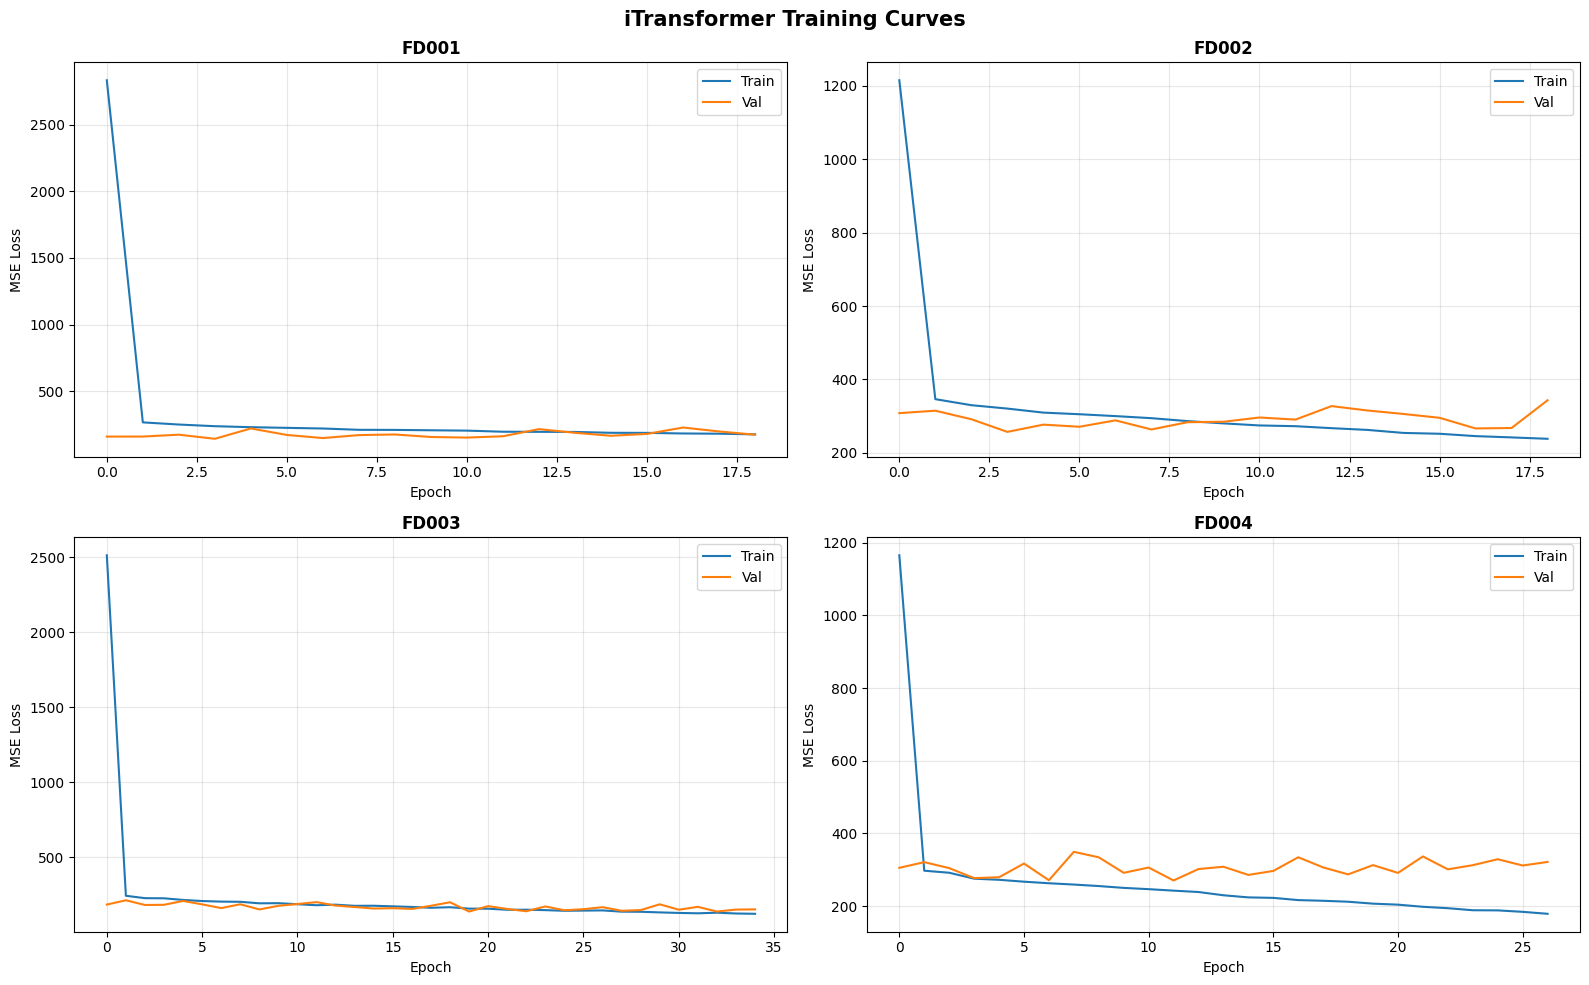

✅ Loss curves saved


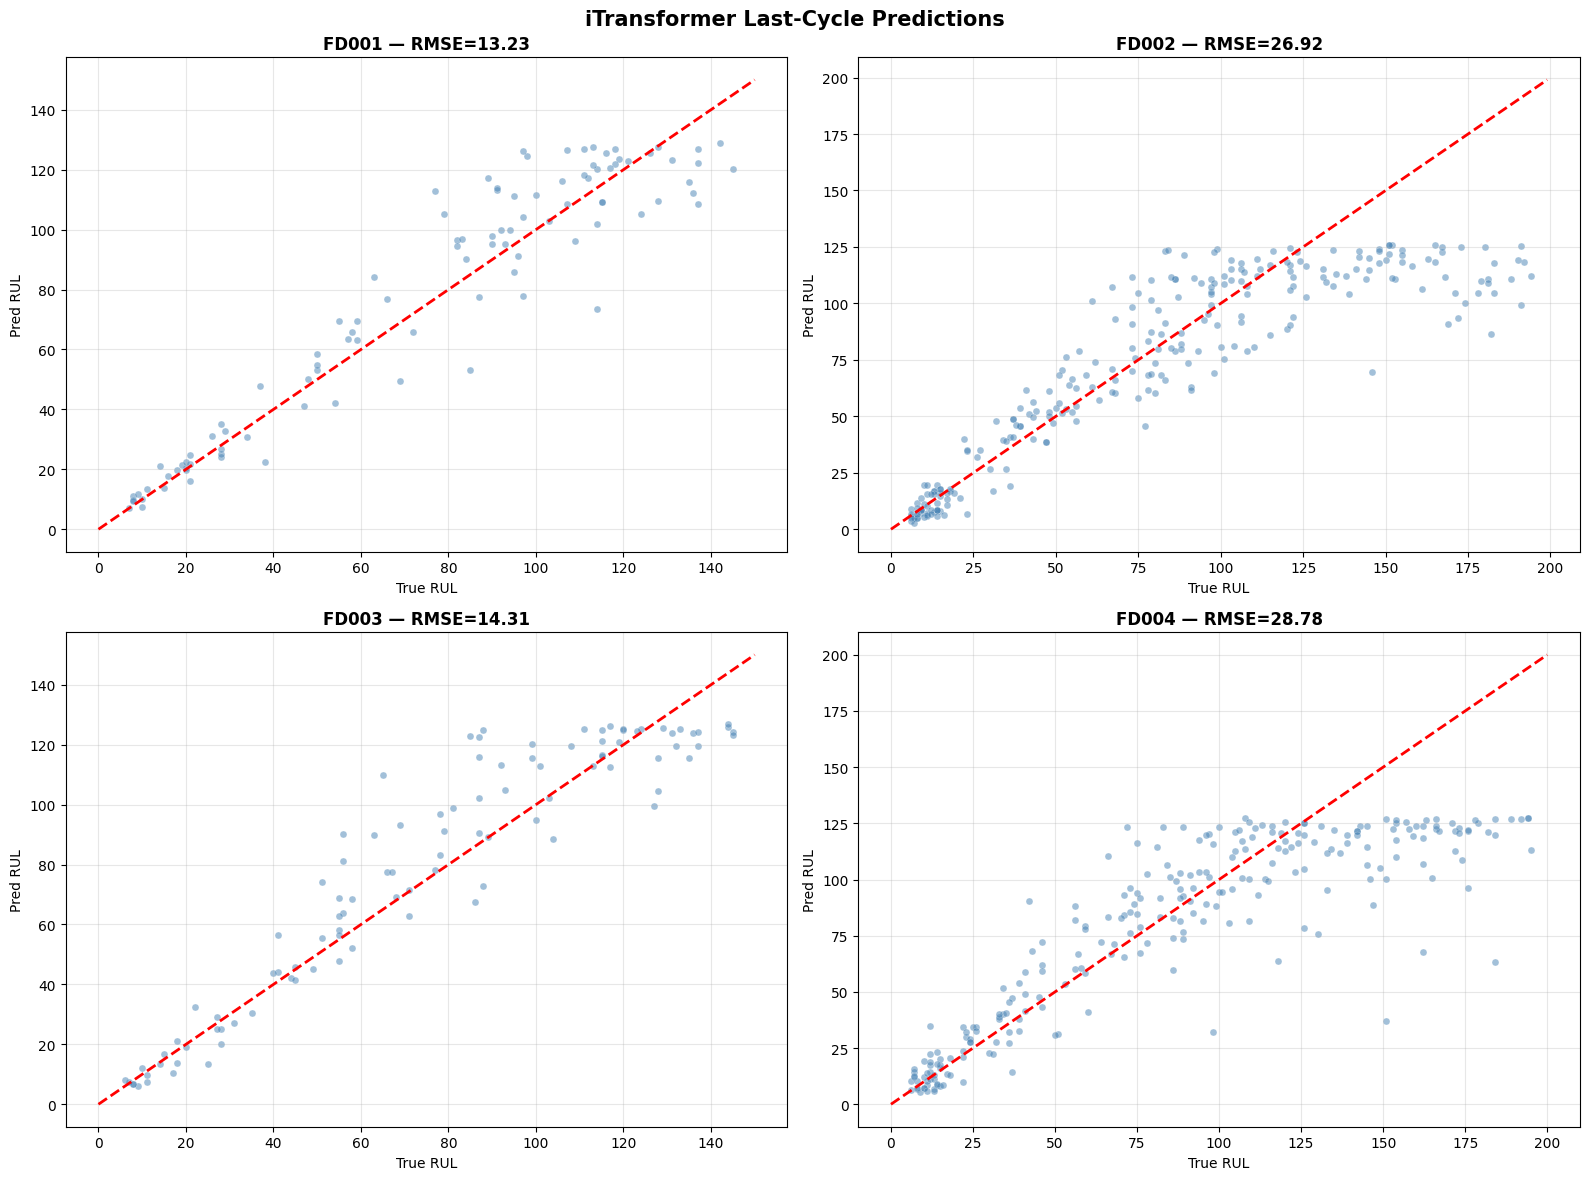

✅ Scatter plots saved


In [7]:
# ============================================================
# Cell 8: Summary, Plots & Export
# ============================================================
import matplotlib.pyplot as plt
import sklearn.metrics as me

# ---- Summary table ----
df_results = pd.DataFrame(list(results.values()))
print("\n" + "="*70)
print("  iTransformer RUL — ALL SUBSETS")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)
df_results.to_csv("/content/itransformer_summary.csv", index=False)
print("\n✅ Summary saved to /content/itransformer_summary.csv")

# ---- Loss curves ----
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, s in zip(axes.flat, ['FD001','FD002','FD003','FD004']):
    h = all_histories[s]
    ax.plot(h['train_loss'], label='Train')
    ax.plot(h['val_loss'],   label='Val')
    ax.set_title(s, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('iTransformer Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/itransformer_loss_curves.png', dpi=150)
plt.show()
print("✅ Loss curves saved")

# ---- Scatter plots ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, s in zip(axes.flat, ['FD001','FD002','FD003','FD004']):
    dl = pd.read_csv(f'/content/itransformer_{s}_lastcycle.csv')
    ax.scatter(dl['true'], dl['pred'], alpha=0.5, s=25,
               c='steelblue', edgecolors='white', linewidth=0.3)
    lim = max(dl['true'].max(), dl['pred'].max()) + 5
    ax.plot([0,lim],[0,lim],'r--',lw=2)
    r = results[s]
    ax.set_title(f"{s} — RMSE={r['RMSE']:.2f}", fontweight='bold')
    ax.set_xlabel('True RUL'); ax.set_ylabel('Pred RUL')
    ax.grid(True, alpha=0.3)
plt.suptitle('iTransformer Last-Cycle Predictions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/itransformer_scatter.png', dpi=150)
plt.show()
print("✅ Scatter plots saved")


In [8]:
# ============================================================
# Cell 9: Download All Results
# ============================================================
try:
    from google.colab import files

    dl = [
        "/content/itransformer_summary.csv",
        "/content/itransformer_loss_curves.png",
        "/content/itransformer_scatter.png",
    ]
    for s in ['FD001','FD002','FD003','FD004']:
        dl += [
            f"/content/itransformer_{s}_predictions.csv",
            f"/content/itransformer_{s}_lastcycle.csv",
            f"/content/itransformer_{s}.pt",
        ]
    for f in dl:
        if os.path.exists(f):
            files.download(f)
            print(f"✅ Downloaded: {f}")

    print("\n📥 All files downloaded successfully!")

except ImportError:
    print("ℹ️  Not in Colab — files saved at /content/")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: /content/itransformer_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: /content/itransformer_FD004_lastcycle.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: /content/itransformer_FD004.pt

📥 All files downloaded successfully!
